# Clustering Netflix Movies with K-Means

**Joe Eldredge** · UVA School of Data Science · Netflix ratings team project

Our team built models to predict movie scores on the Netflix Prize dataset (~100M ratings, 17,770 movies).
Before moving to learning with unlabeled data, I used k-means clustering as an *exploration* tool: do movies
form organic clusters based on **who** rates them and **how**?

**Feature design.** Each movie is represented by a sparse 1,000-dimensional vector: its average rating from
each of the 1,000 most active reviewers (movies pivoted against power users, missing ratings filled with 0).
Features were standardized, then clustered with Spark MLlib's `KMeans` inside a
`VectorAssembler → StandardScaler → KMeans` pipeline.

> The original pipeline ran on a Spark cluster against the full Netflix Prize data, which is too large to ship
> with this notebook. The figures below are built from the **recorded results of that run**; the full PySpark
> code is preserved in the appendix.

## 1. How many clusters? Silhouette scores for $k = 2 \ldots 10$

We swept $k$ from 2 to 10 and computed the silhouette score (cosine-squared-Euclidean, Spark's
`ClusteringEvaluator`) for each.

Matplotlib is building the font cache; this may take a moment.


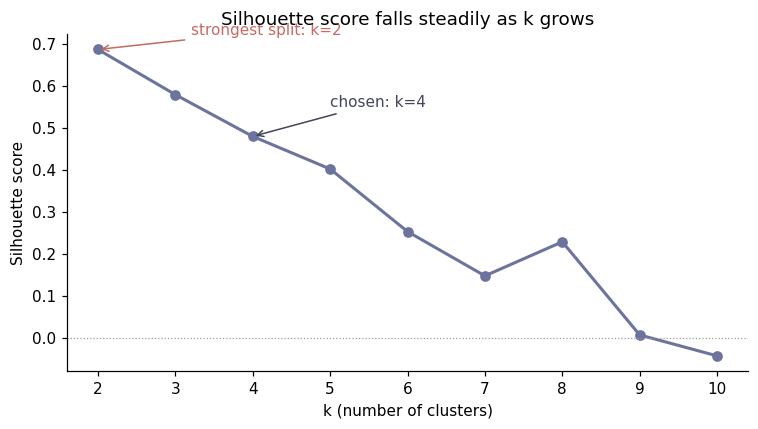

,k,sil_score
0,2,0.686687
1,3,0.579240
2,4,0.479950
3,5,0.402497
4,6,0.253708
5,8,0.229335
6,7,0.148384
7,9,0.007956
8,10,-0.041877


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = {"purple": "#6C739C", "dark": "#424658", "copper": "#C56B62", "tan": "#DEA785"}

# Recorded silhouette scores from the Spark run (standardized features, max_iter=3, seed=314)
k_sweep = pd.DataFrame({
    "k":         [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "sil_score": [0.686687, 0.579240, 0.479950, 0.402497, 0.253708,
                  0.148384, 0.229335, 0.007956, -0.041877],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_sweep["k"], k_sweep["sil_score"], marker="o", color=PALETTE["purple"], lw=2)
ax.axhline(0, color="#999", lw=0.8, ls=":")
ax.annotate("strongest split: k=2", xy=(2, 0.6867), xytext=(3.2, 0.72),
            arrowprops=dict(arrowstyle="->", color=PALETTE["copper"]), color=PALETTE["copper"])
ax.annotate("chosen: k=4", xy=(4, 0.4800), xytext=(5.0, 0.55),
            arrowprops=dict(arrowstyle="->", color=PALETTE["dark"]), color=PALETTE["dark"])
ax.set_xlabel("k (number of clusters)")
ax.set_ylabel("Silhouette score")
ax.set_title("Silhouette score falls steadily as k grows")
plt.tight_layout()
plt.show()

k_sweep.sort_values("sil_score", ascending=False).reset_index(drop=True)

**Reading the curve.** The best-separated structure is the coarsest one: at $k=2$ the silhouette is a
strong 0.69, and every additional cluster costs separation quality, going roughly linearly toward zero by
$k=9$. In other words, in rating-profile space the catalog mostly splits into **two broad groups** — movies
heavily rated by power users versus movies with sparse profiles — and finer partitions cut through
genuinely overlapping regions.

We still selected $k=4$ for the analysis: a moderate silhouette (~0.48–0.56 depending on iterations)
in exchange for segments fine-grained enough to be interpretable.

## 2. Does more training help? Tuning `max_iter`

We re-ran the sweep across `max_iter` ∈ {1, 3, 5, 10, 20, 30, 40, 50, 100}. The table below shows the
top recorded configurations; the chart tracks $k=2$ across iteration budgets.

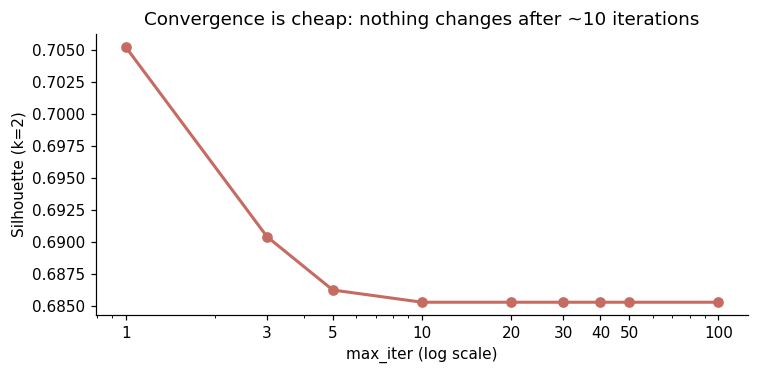

,max_iter,k,sil_score
0,1,2,0.705261
1,3,2,0.690397
2,5,2,0.686225
3,10,2,0.685270
4,20,2,0.685270
5,30,2,0.685270
6,40,2,0.685270
7,50,2,0.685270
8,100,2,0.685270
9,20,4,0.556725


In [2]:
# Top recorded configurations from the tuning grid (standardized features, seed=314)
tuned = pd.DataFrame({
    "max_iter":  [1, 3, 5, 10, 20, 30, 40, 50, 100, 20],
    "k":         [2, 2, 2, 2,  2,  2,  2,  2,  2,   4],
    "sil_score": [0.705261, 0.690397, 0.686225, 0.685270, 0.685270,
                  0.685270, 0.685270, 0.685270, 0.685270, 0.556725],
})

k2 = tuned[tuned["k"] == 2]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(k2["max_iter"], k2["sil_score"], marker="o", color=PALETTE["copper"], lw=2)
ax.set_xscale("log")
ax.set_xticks(k2["max_iter"]); ax.set_xticklabels(k2["max_iter"])
ax.set_xlabel("max_iter (log scale)")
ax.set_ylabel("Silhouette (k=2)")
ax.set_title("Convergence is cheap: nothing changes after ~10 iterations")
plt.tight_layout()
plt.show()

tuned

**Reading the table.** Convergence is essentially free: by `max_iter=10` the silhouette is identical out
to 100 iterations (0.685270). The *slightly higher* score at `max_iter=1` (0.705) is an artifact — barely-moved
centroids can luck into a marginally better silhouette without representing a converged solution. Practical
takeaway for the pipeline: a small iteration budget (10–20) is enough, which matters when each fit runs over a
movie × 1,000-user matrix on a shared cluster. The best $k=4$ configuration (`max_iter=20`) scored 0.5567.

## 3. What do the clusters mean? Average rating by cluster

The final pipeline (`k=4`, `max_iter=20`) assigned every movie to a cluster. Joining assignments back to the
underlying reviews gives each cluster's average rating.

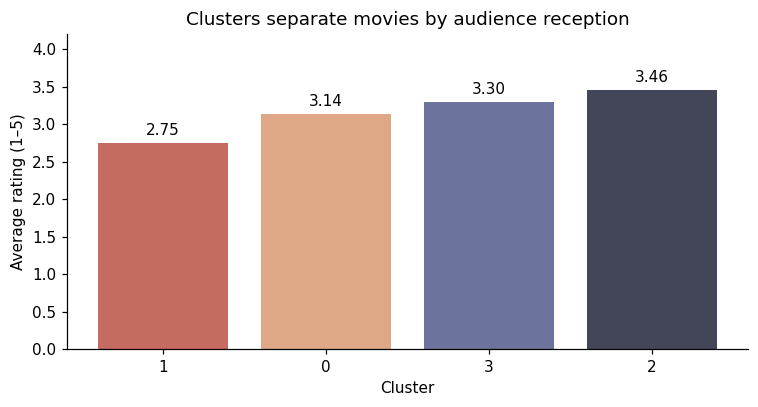

In [3]:
# Recorded cluster-level average ratings from the final k=4 model
clusters = pd.DataFrame({
    "cluster":    [1, 0, 3, 2],
    "avg_rating": [2.7536, 3.1378, 3.2961, 3.4589],
})

fig, ax = plt.subplots(figsize=(7, 3.8))
colors = [PALETTE["copper"], PALETTE["tan"], PALETTE["purple"], PALETTE["dark"]]
bars = ax.bar(clusters["cluster"].astype(str), clusters["avg_rating"], color=colors)
ax.bar_label(bars, fmt="%.2f", padding=3)
ax.set_ylim(0, 4.2)
ax.set_xlabel("Cluster")
ax.set_ylabel("Average rating (1–5)")
ax.set_title("Clusters separate movies by audience reception")
plt.tight_layout()
plt.show()

## Insights

**The clusters track audience reception, not just structure.** Although k-means saw only *who* rated each
movie and *what they gave it* — never an explicit quality label — the resulting segments span a meaningful
gap in average rating, from 2.75 to 3.46 on a 5-point scale. One cluster collects poorly received movies,
another collects crowd-pleasers, with two middling groups between. That makes cluster membership a
candidate *feature* for the downstream rating-prediction models, and a useful lens for exploring the catalog.

**The dominant structure is two-way, finer structure is real but soft.** The silhouette curve says the
cleanest split is binary; $k=4$ trades separation for interpretability. This shaped how the team treated
clustering in the larger project — as data exploration informing supervised models, not as a recommender
on its own.

**Operational lessons.** Convergence needed only ~10 iterations, and standardizing features made no
material difference for this sparse pivot. One caveat worth remembering: k-means cluster *labels* are
arbitrary and can permute between runs (our standalone fit and pipeline re-fit numbered the same groups
differently), so clusters should always be interpreted by their contents, not their index.

---
## Appendix: original PySpark pipeline (reference)

The code below is the original cluster-side implementation, preserved for reference (it requires the
Netflix Prize CSVs and a Spark cluster to run).

```python
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import col, expr
from pyspark.sql.types import IntegerType
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline

spark = SparkSession.builder.getOrCreate()

# Load ratings and movie metadata; drop movies with null year/name
reviews_df = spark.read.csv("formatted_data.csv", header=True, inferSchema=True)
movies_df = (spark.read.csv("movie_titles.csv", header=False, inferSchema=True)
             .select(col("_c0").alias("movie_id"),
                     col("_c1").alias("movie_year").cast(IntegerType()),
                     col("_c2").alias("movie_name")))
null_ids = [r[0] for r in movies_df.filter(col("movie_year").isNull() |
            (col("movie_name") == "NULL")).select("movie_id").collect()]
movies_df = movies_df.filter(~movies_df.movie_id.isin(null_ids))
reviews_df = reviews_df.filter(~reviews_df.movie_id.isin(null_ids))

# Keep the 1,000 most active reviewers; engineer movie_age
top_users = [int(r[0]) for r in (reviews_df.groupBy("user_id").agg(F.count("rating"))
             .sort(F.desc("count(rating)")).limit(1000).select("user_id").collect())]
train = reviews_df.filter(reviews_df.user_id.isin(top_users))
rm = movies_df.join(train, on=["movie_id"])
rm = rm.withColumn("year_trunc", expr("substring(date,0,4)"))
rm = rm.withColumn("movie_age",
                   rm.year_trunc.cast(IntegerType()) - rm.movie_year.cast(IntegerType()))
df_for_kmeans = rm.drop("date", "year_trunc", "movie_name")

# Pivot: one row per movie, one column per power user (avg rating, NA -> 0)
spark.conf.set("spark.sql.pivotMaxValues", "100000")
pivoted = df_for_kmeans.groupBy("movie_id").pivot("user_id").avg("rating").fillna(0)

# Silhouette sweep over k (and a max_iter grid in the tuned variant)
def kmeans_range(lower, upper, dat, features):
    evaluator, rows = ClusteringEvaluator(), []
    for k in range(lower, upper + 1):
        model = (KMeans(featuresCol=features).setK(k).setSeed(314)
                 .setMaxIter(3).fit(dat))
        rows.append((k, evaluator.evaluate(model.transform(dat))))
    return rows

# Final model as a reusable pipeline
assembler = VectorAssembler(
    inputCols=[c for c in pivoted.columns if c != "movie_id"],
    outputCol="features", handleInvalid="skip")
scaler = StandardScaler(inputCol="features", outputCol="standardized")
kmeans = KMeans(featuresCol="standardized").setK(4).setSeed(314).setMaxIter(20)
pipeline_model = Pipeline(stages=[assembler, scaler, kmeans]).fit(pivoted)
pipeline_model.write().overwrite().save("kmeans_model")

# Cluster-level average ratings
preds = pipeline_model.transform(pivoted).select("movie_id", "prediction")
preds.join(train, on=["movie_id"]).groupBy("prediction") \
     .agg(F.avg("rating").alias("avg_rating")).show()
```